In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("DateFruit_Dataset.csv")

In [4]:
df.head()
df.shape

(898, 35)

In [5]:
X = df.drop("Class", axis=1).values
y = df["Class"].values


df[class_counts := "Class"].value_counts()


Class
DOKOL     204
SAFAVI    199
ROTANA    166
DEGLET     98
SOGAY      94
IRAQI      72
BERHI      65
Name: count, dtype: int64

In [6]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)




In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [10]:
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [11]:
train_loader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

In [12]:
# Define the ANN Classification model

class ANNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(ANNClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x 



In [13]:
model = ANNClassifier(input_size=X.shape[1], hidden_size=64, num_classes=len(le.classes_))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
EPOCHS = 20

for epochs in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    train_loss = running_loss / len(train_loader)
    print(f"Epoch {epochs+1}/{EPOCHS}, Loss: {train_loss:.4f}") 

    model.eval()


Epoch 1/20, Loss: 1.5734
Epoch 2/20, Loss: 1.0813
Epoch 3/20, Loss: 0.8122
Epoch 4/20, Loss: 0.6644
Epoch 5/20, Loss: 0.5751
Epoch 6/20, Loss: 0.5060
Epoch 7/20, Loss: 0.4696
Epoch 8/20, Loss: 0.4272
Epoch 9/20, Loss: 0.3974
Epoch 10/20, Loss: 0.3689
Epoch 11/20, Loss: 0.3471
Epoch 12/20, Loss: 0.3236
Epoch 13/20, Loss: 0.3006
Epoch 14/20, Loss: 0.2873
Epoch 15/20, Loss: 0.2743
Epoch 16/20, Loss: 0.2667
Epoch 17/20, Loss: 0.2584
Epoch 18/20, Loss: 0.2488
Epoch 19/20, Loss: 0.2381
Epoch 20/20, Loss: 0.2284


In [15]:
total = 0
correct = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs = model(x_batch)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")
print(total, correct)


Test Accuracy: 0.9389
180 169


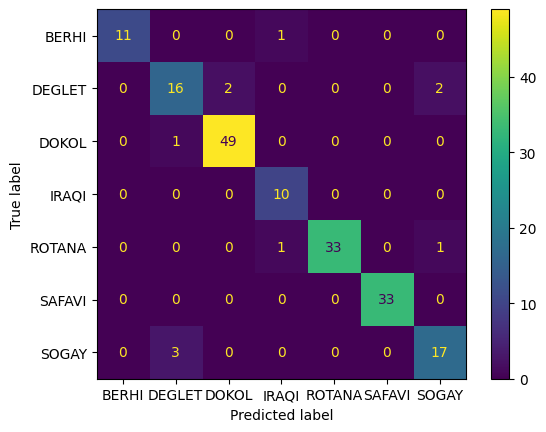

In [16]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        outputs = model(x_batch)
        y_pred.extend(torch.max(outputs, 1)[1].cpu().numpy())   
y_test = le.inverse_transform(y_test)
y_pred = le.inverse_transform(y_pred)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.show()